# 01. Estadística descriptiva
 
Este archivo prepara la base `DataFrameBabyFaceValidacion.xlsx`, limpia tokens de error como `FIT_FAILED`, normaliza tiempos y produce una primera exploración descriptiva.

La lectura del problema en la primera entrega se centra en trayectorias emocionales de **valencia** y **activación/arousal** para estudiar aceptación, exploración y rechazo ante exposiciones alimentarias.

## 1. Carga, limpieza y variables derivadas

Decisiones de limpieza adicionales:

- `FIT_FAILED`, `FIT FAILED`, `FIND_FAILED`, `-`, `S/I`, `NA` y variantes se tratan como valores faltantes.
- Tiempos tipo `00:00:02.200` se convierten a segundos.
- Tiempos guardados como milisegundos, por ejemplo `16433`, se convierten a `16.433` segundos.
- Etiquetas de día como `7E`, `7P`, `1E 2` o `4.2` se separan en `dia_num` y `fase_dia`.
- Se crean promedios y deltas de valencia/arousal para resumir trayectorias emocionales.

In [ ]:
from pathlib import Path
import re
import math
import itertools
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_CANDIDATES = [
    Path("DataFrameBabyFaceValidacion.xlsx"),
    Path("/mnt/data/DataFrameBabyFaceValidacion.xlsx"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró DataFrameBabyFaceValidacion.xlsx. Coloca el Excel en la misma carpeta del notebook.")

OUTPUT_DIR = Path("babyface_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

MISSING_TOKENS = {'', '-', 'NA', 'NA ', 'N/A', 'nan', 'NaN', 'FIT_FAILED', 'FIT FAILED', 'FIND_FAILED', 'S/I', None}

def parse_time_to_seconds(x):
    """Convierte tiempos a segundos. Maneja segundos, milisegundos y formatos tipo HH:MM:SS.mmm."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        value = float(x)
        # Algunos registros están en milisegundos: 16433 -> 16.433 s.
        return value / 1000 if value > 1000 else value
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    if ':' in s:
        try:
            parts = [p.strip() for p in s.split(':')]
            if len(parts) == 3:
                h, m, sec = parts
                return float(h) * 3600 + float(m) * 60 + float(sec)
            if len(parts) == 2:
                m, sec = parts
                return float(m) * 60 + float(sec)
        except Exception:
            pass
    # Casos como 1.00.60 o 1,34,033: se interpretan como minutos, segundos y fracción.
    if re.fullmatch(r'\d+[\.,]\d+[\.,]\d+', s):
        nums = [int(p) for p in re.split(r'[\.,]', s)]
        if len(nums) == 3:
            minutes, seconds, frac = nums
            return minutes * 60 + seconds + frac / (10 ** len(str(frac)))
    try:
        value = float(s.replace(',', '.'))
        return value / 1000 if value > 1000 else value
    except Exception:
        return np.nan

def parse_numeric(x):
    """Convierte a float y manda tokens de error/missing a NaN."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    try:
        return float(s.replace(',', '.'))
    except Exception:
        return np.nan

def parse_day_number(x):
    """Extrae el número de día de etiquetas mixtas como 7E, 7P, 1E 2, 4.2."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    match = re.search(r'\d+(?:\.\d+)?', s)
    return float(match.group(0)) if match else np.nan

def parse_phase(x):
    """Extrae si la etiqueta de día tiene E, P, ambas o ninguna."""
    if pd.isna(x):
        return "sin_fase"
    s = str(x).strip().upper()
    if s in MISSING_TOKENS:
        return "sin_fase"
    has_e = 'E' in s
    has_p = 'P' in s
    if has_e and has_p:
        return "E/P"
    if has_e:
        return "E"
    if has_p:
        return "P"
    return "sin_fase"

def load_and_clean(path=DATA_PATH):
    raw = pd.read_excel(path)
    df = raw.copy()

    # Normalización de comentarios y día.
    df['comentarios'] = df['comentarios'].replace({'NA': np.nan, 'NA ': np.nan, '-': np.nan})
    df['dia_original'] = df['dia'].astype(str)
    df['dia_num'] = df['dia'].apply(parse_day_number)
    df['fase_dia'] = df['dia'].apply(parse_phase)

    time_cols = ['t_total', 't_prueba1', 't_prueba2']
    binary_cols = ['rechaza', 'llora', 'toca', 'prueba', 'consume']
    va_cols = [c for c in df.columns if c.startswith('valence') or c.startswith('arousal')]

    for c in time_cols:
        df[c] = df[c].apply(parse_time_to_seconds)
    for c in binary_cols:
        df[c] = df[c].apply(parse_numeric)
    for c in va_cols:
        df[c] = df[c].apply(parse_numeric)

    valence_cols = [c for c in df.columns if c.startswith('valence')]
    arousal_cols = [c for c in df.columns if c.startswith('arousal')]

    # Variables derivadas para EDA y TDA.
    df['valence_mean'] = df[valence_cols].mean(axis=1, skipna=True)
    df['arousal_mean'] = df[arousal_cols].mean(axis=1, skipna=True)
    df['valence_delta'] = df['valence_final'] - df['valence_inicio']
    df['arousal_delta'] = df['arousal_final'] - df['arousal_inicio']
    df['valence_p1_delta'] = df['valence_p1_after'] - df['valence_p1_before']
    df['valence_p2_delta'] = df['valence_p2_after'] - df['valence_p2_before']
    df['arousal_p1_delta'] = df['arousal_p1_after'] - df['arousal_p1_before']
    df['arousal_p2_delta'] = df['arousal_p2_after'] - df['arousal_p2_before']
    df['aceptacion_score'] = df[['prueba','consume']].mean(axis=1, skipna=True) - df[['rechaza','llora']].mean(axis=1, skipna=True)
    df['va_missing_count'] = df[valence_cols + arousal_cols].isna().sum(axis=1)
    return raw, df

raw, df = load_and_clean()
print(f"Archivo cargado: {DATA_PATH}")
print(f"Dimensiones raw: {raw.shape[0]} filas x {raw.shape[1]} columnas")
print(f"Dimensiones cleaned: {df.shape[0]} filas x {df.shape[1]} columnas")

Archivo cargado: DataFrameBabyFaceValidacion.xlsx
Dimensiones raw: 366 filas x 27 columnas
Dimensiones cleaned: 366 filas x 40 columnas


In [ ]:
# Vista rápida de los primeros registros ya limpiados.
cols_preview = ['id','dia','dia_num','fase_dia','t_total','rechaza','llora','toca','prueba','consume','valence_final','arousal_final','comentarios']
df[cols_preview].head(12)

,id,dia,dia_num,fase_dia,t_total,rechaza,llora,toca,prueba,consume,valence_final,arousal_final,comentarios
0,ID1,1,1.0,sin_fase,10.46,0.0,0.0,0.0,1.0,1.0,0.332397,0.740125,NaN
1,ID1,2,2.0,sin_fase,15.30,0.0,0.0,0.0,1.0,1.0,0.088369,0.898387,NaN
2,ID1,3,3.0,sin_fase,22.16,0.0,0.0,0.0,1.0,1.0,0.080915,0.774763,NaN
3,ID1,4,4.0,sin_fase,24.39,0.0,0.0,0.0,1.0,1.0,0.114489,0.656871,"Sólo lo consume la 1ra vez, 2da sólo pruba"
4,ID1,5,5.0,sin_fase,30.03,0.0,0.0,0.0,1.0,0.0,0.069620,0.708141,NaN
5,ID1,6,6.0,sin_fase,18.06,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN
6,ID1,7,7.0,sin_fase,24.56,0.0,0.0,0.0,1.0,1.0,0.370860,0.759927,Lo consume sólo la 2da vez
7,ID1,8,8.0,sin_fase,16.13,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN
8,ID1,9,9.0,sin_fase,33.16,0.0,0.0,0.0,1.0,0.0,NaN,NaN,"Primeras 2 veces lo prueba, al 4to intento lo ..."
9,ID1,10,10.0,sin_fase,37.33,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN


## 2. Diccionario operativo de variables

In [ ]:
variable_groups = {
    'Identificación / exposición': ['id', 'dia', 'dia_num', 'fase_dia'],
    'Tiempos': ['t_total', 't_prueba1', 't_prueba2'],
    'Conducta observable': ['rechaza', 'llora', 'toca', 'prueba', 'consume'],
    'Valencia': [c for c in df.columns if c.startswith('valence')],
    'Arousal / activación': [c for c in df.columns if c.startswith('arousal')],
    'Texto': ['comentarios'],
    'Derivadas': ['valence_mean', 'arousal_mean', 'valence_delta', 'arousal_delta', 'aceptacion_score', 'va_missing_count']
}
rows = []
for group, cols in variable_groups.items():
    for col in cols:
        if col in df.columns:
            rows.append({'grupo': group, 'variable': col, 'tipo': str(df[col].dtype), 'missing_%': round(df[col].isna().mean() * 100, 2)})
data_dictionary = pd.DataFrame(rows)
data_dictionary.to_csv(OUTPUT_DIR / '01_diccionario_variables.csv', index=False)
data_dictionary

,grupo,variable,tipo,missing_%
0,Identificación / exposición,id,object,0.00
1,Identificación / exposición,dia,object,0.00
2,Identificación / exposición,dia_num,float64,0.27
3,Identificación / exposición,fase_dia,object,0.00
4,Tiempos,t_total,float64,0.82
5,Tiempos,t_prueba1,float64,19.67
6,Tiempos,t_prueba2,float64,52.46
7,Conducta observable,rechaza,float64,0.82
8,Conducta observable,llora,float64,1.09
9,Conducta observable,toca,float64,0.82


## 3. Cobertura general de datos

In [ ]:
general_summary = pd.DataFrame({
    'métrica': ['filas', 'columnas_raw', 'columnas_cleaned', 'infantes_id', 'dia_min', 'dia_max', 'registros_con_comentario'],
    'valor': [len(df), raw.shape[1], df.shape[1], df['id'].nunique(), df['dia_num'].min(), df['dia_num'].max(), df['comentarios'].notna().sum()]
})
general_summary.to_csv(OUTPUT_DIR / '01_resumen_general.csv', index=False)
general_summary

,métrica,valor
0,filas,366.0
1,columnas_raw,27.0
2,columnas_cleaned,40.0
3,infantes_id,20.0
4,dia_min,1.0
5,dia_max,21.0
6,registros_con_comentario,254.0


In [ ]:
phase_counts = df['fase_dia'].value_counts(dropna=False).rename_axis('fase_dia').reset_index(name='n')
phase_counts['porcentaje'] = (phase_counts['n'] / len(df) * 100).round(2)
phase_counts.to_csv(OUTPUT_DIR / '01_fase_dia_counts.csv', index=False)
phase_counts

,fase_dia,n,porcentaje
0,sin_fase,167,45.63
1,E,122,33.33
2,P,76,20.77
3,E/P,1,0.27


## 4. Valores faltantes y calidad de datos

In [ ]:
missing = (df.isna().mean() * 100).sort_values(ascending=False).reset_index()
missing.columns = ['variable', 'missing_%']
missing['missing_%'] = missing['missing_%'].round(2)
missing.to_csv(OUTPUT_DIR / '01_missingness.csv', index=False)
missing.head(18)

,variable,missing_%
0,arousal_p2_delta,59.02
1,valence_p2_delta,59.02
2,arousal_p2_before,57.65
3,valence_p2_before,57.65
4,arousal_p2_after,56.28
5,valence_p2_after,56.28
6,arousal_p2_during,55.46
7,valence_p2_during,55.19
8,t_prueba2,52.46
9,arousal_p1_delta,37.98


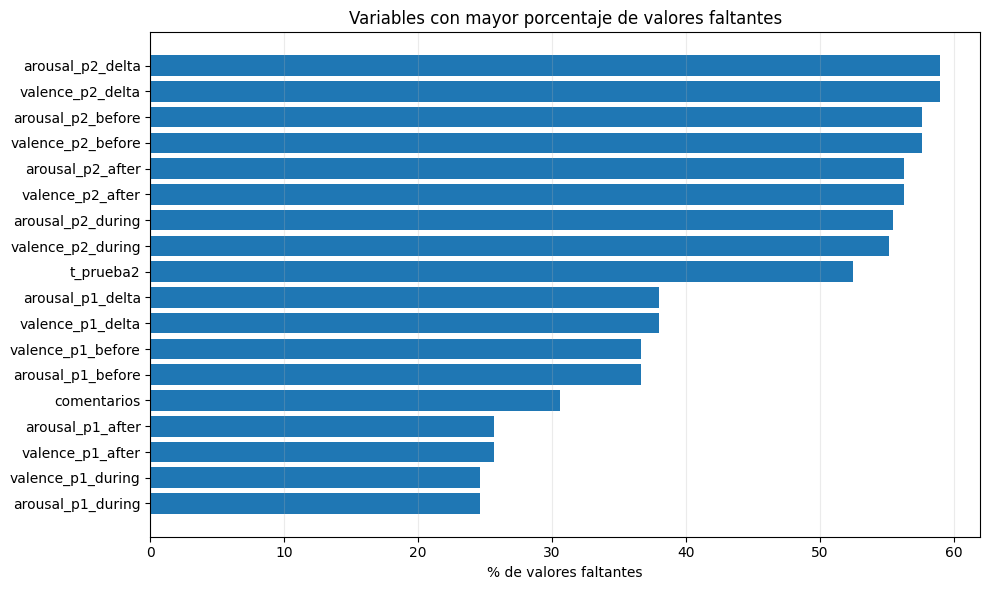

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
top_missing = missing.head(18).iloc[::-1]
ax.barh(top_missing['variable'], top_missing['missing_%'])
ax.set_xlabel('% de valores faltantes')
ax.set_title('Variables con mayor porcentaje de valores faltantes')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '01_missingness.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Frecuencias de variables conductuales

In [ ]:
binary_cols = ['rechaza','llora','toca','prueba','consume']
binary_rates = pd.DataFrame({
    'variable': binary_cols,
    'tasa_1': [df[c].mean(skipna=True) for c in binary_cols],
    'n_validos': [df[c].notna().sum() for c in binary_cols]
})
binary_rates['tasa_1'] = binary_rates['tasa_1'].round(3)
binary_rates.to_csv(OUTPUT_DIR / '01_binary_rates.csv', index=False)
binary_rates

,variable,tasa_1,n_validos
0,rechaza,0.444,363
1,llora,0.055,362
2,toca,0.554,363
3,prueba,0.680,363
4,consume,0.562,363


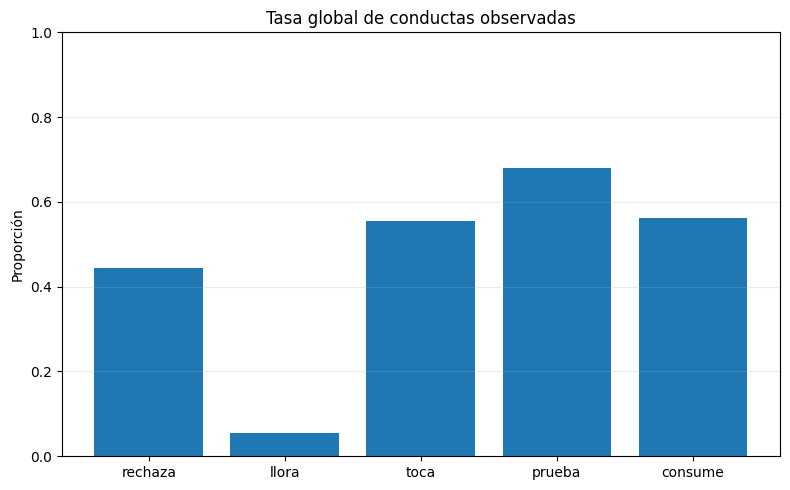

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(binary_rates['variable'], binary_rates['tasa_1'])
ax.set_ylim(0, 1)
ax.set_ylabel('Proporción')
ax.set_title('Tasa global de conductas observadas')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '01_binary_rates.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Estadística descriptiva de tiempos, valencia y arousal

In [ ]:
summary_cols = [
    't_total','t_prueba1','t_prueba2',
    'valence_inicio','arousal_inicio',
    'valence_final','arousal_final',
    'valence_mean','arousal_mean',
    'valence_delta','arousal_delta',
    'aceptacion_score'
]
numeric_summary = df[summary_cols].describe(percentiles=[.25,.5,.75]).T.round(3)
numeric_summary.to_csv(OUTPUT_DIR / '01_numeric_summary.csv')
numeric_summary

,count,mean,std,min,25%,50%,75%,max
t_total,363.0,18.069,11.711,1.700,10.330,15.500,23.365,94.330
t_prueba1,294.0,4.289,5.580,0.000,0.900,2.225,5.105,32.890
t_prueba2,174.0,14.290,8.372,2.720,8.925,12.055,16.290,58.300
valence_inicio,330.0,0.194,0.147,0.056,0.092,0.133,0.253,0.761
arousal_inicio,330.0,0.373,0.293,0.000,0.101,0.346,0.570,0.990
valence_final,345.0,0.181,0.117,0.054,0.106,0.146,0.217,0.867
arousal_final,345.0,0.457,0.203,0.012,0.308,0.446,0.591,0.990
valence_mean,357.0,0.208,0.107,0.079,0.133,0.178,0.254,0.714
arousal_mean,357.0,0.454,0.197,0.023,0.318,0.457,0.587,0.990
valence_delta,318.0,-0.009,0.161,-0.657,-0.068,0.009,0.066,0.619


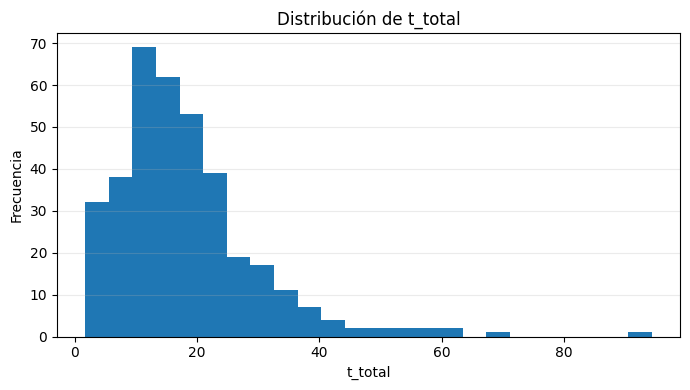

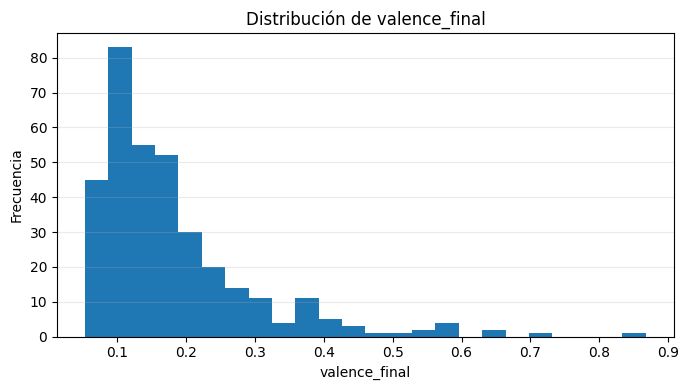

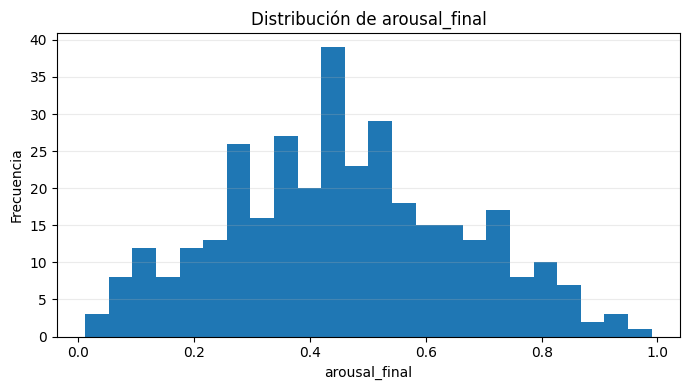

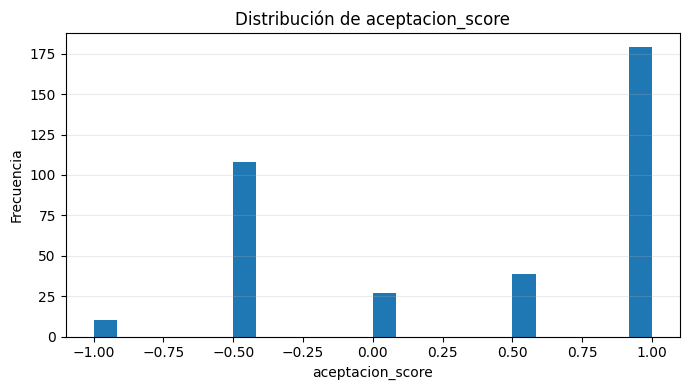

In [ ]:
for col in ['t_total', 'valence_final', 'arousal_final', 'aceptacion_score']:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(df[col].dropna(), bins=24)
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f'01_hist_{col}.png', dpi=160, bbox_inches='tight')
    plt.show()

## 7. Resumen por infante

In [ ]:
by_id = df.groupby('id').agg(
    n_registros=('dia_num','count'),
    primer_dia=('dia_num','min'),
    ultimo_dia=('dia_num','max'),
    consume_rate=('consume','mean'),
    prueba_rate=('prueba','mean'),
    rechaza_rate=('rechaza','mean'),
    llora_rate=('llora','mean'),
    toca_rate=('toca','mean'),
    valence_final_media=('valence_final','mean'),
    arousal_final_media=('arousal_final','mean'),
    valence_delta_media=('valence_delta','mean'),
    arousal_delta_media=('arousal_delta','mean'),
    t_total_mediana=('t_total','median'),
    comentarios_n=('comentarios','count')
).reset_index()
first_consume = df[df['consume'] == 1].groupby('id')['dia_num'].min().rename('primer_dia_consume')
by_id = by_id.merge(first_consume, on='id', how='left')
by_id = by_id.sort_values('id', key=lambda s: s.str.replace('ID','').astype(int))
by_id.round(3).to_csv(OUTPUT_DIR / '01_resumen_por_id.csv', index=False)
by_id.round(3)

,id,n_registros,primer_dia,ultimo_dia,consume_rate,prueba_rate,rechaza_rate,llora_rate,toca_rate,valence_final_media,arousal_final_media,valence_delta_media,arousal_delta_media,t_total_mediana,comentarios_n,primer_dia_consume
0,ID1,15,1.0,15.0,0.867,1.000,0.000,0.000,0.000,0.160,0.647,-0.025,0.064,21.290,6,1.0
11,ID2,6,1.0,6.0,0.833,0.833,0.333,0.200,0.000,0.117,0.718,-0.050,0.330,20.245,2,1.0
13,ID3,19,1.0,17.0,0.474,0.895,0.316,0.000,0.000,0.132,0.745,-0.058,0.081,20.960,9,1.0
14,ID4,18,1.0,17.0,0.722,0.889,0.611,0.444,0.667,0.417,0.709,-0.005,-0.002,13.660,0,1.0
15,ID5,16,1.0,16.0,0.938,0.875,0.250,0.000,0.125,0.112,0.525,-0.055,0.036,16.630,4,1.0
16,ID6,9,1.0,9.0,0.444,0.444,0.667,0.222,0.000,0.168,0.524,0.046,0.089,16.660,5,1.0
17,ID7,35,2.0,21.0,0.229,0.343,0.857,0.057,0.543,0.228,0.343,0.016,0.064,9.133,35,4.0
18,ID8,26,1.0,20.0,0.538,0.692,0.500,0.000,0.808,0.193,0.387,0.009,0.129,16.400,26,6.0
19,ID9,15,1.0,15.0,1.000,1.000,0.000,0.000,1.000,0.180,0.480,-0.015,0.175,29.960,3,2.0
1,ID10,23,1.0,16.0,0.087,0.435,0.913,0.087,0.478,0.203,0.366,0.030,0.092,10.166,24,13.0


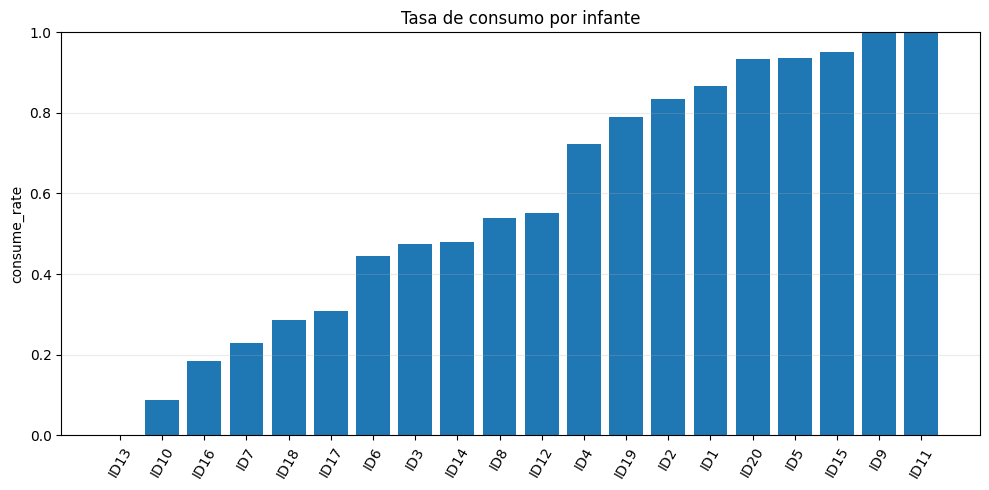

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered = by_id.sort_values('consume_rate')
ax.bar(ordered['id'], ordered['consume_rate'])
ax.set_ylim(0, 1)
ax.set_title('Tasa de consumo por infante')
ax.set_ylabel('consume_rate')
ax.tick_params(axis='x', rotation=60)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '01_consume_rate_por_id.png', dpi=160, bbox_inches='tight')
plt.show()

## 8. Tendencias por día/exposición

In [ ]:
trend_day = df.groupby('dia_num').agg(
    n=('id','count'),
    consume_rate=('consume','mean'),
    prueba_rate=('prueba','mean'),
    rechaza_rate=('rechaza','mean'),
    llora_rate=('llora','mean'),
    valence_final_mean=('valence_final','mean'),
    arousal_final_mean=('arousal_final','mean'),
    aceptacion_score_mean=('aceptacion_score','mean')
).reset_index().sort_values('dia_num')
trend_day.round(3).to_csv(OUTPUT_DIR / '01_tendencia_por_dia.csv', index=False)
trend_day.round(3).head(12)

,dia_num,n,consume_rate,prueba_rate,rechaza_rate,llora_rate,valence_final_mean,arousal_final_mean,aceptacion_score_mean
0,1.0,20,0.421,0.579,0.579,0.053,0.191,0.461,0.184
1,2.0,22,0.591,0.773,0.500,0.045,0.201,0.477,0.409
2,3.0,21,0.381,0.524,0.571,0.143,0.142,0.410,0.095
3,4.0,25,0.440,0.640,0.560,0.125,0.205,0.473,0.180
4,4.2,1,0.000,1.000,1.000,1.000,0.142,0.487,-0.500
5,5.0,26,0.308,0.538,0.615,0.038,0.158,0.476,0.096
6,6.0,23,0.435,0.435,0.609,0.043,0.172,0.432,0.109
7,6.1,1,0.000,0.000,1.000,0.000,0.054,0.990,-0.500
8,6.2,1,0.000,1.000,0.000,0.000,0.071,0.686,0.500
9,7.0,24,0.458,0.625,0.458,0.042,0.194,0.461,0.292


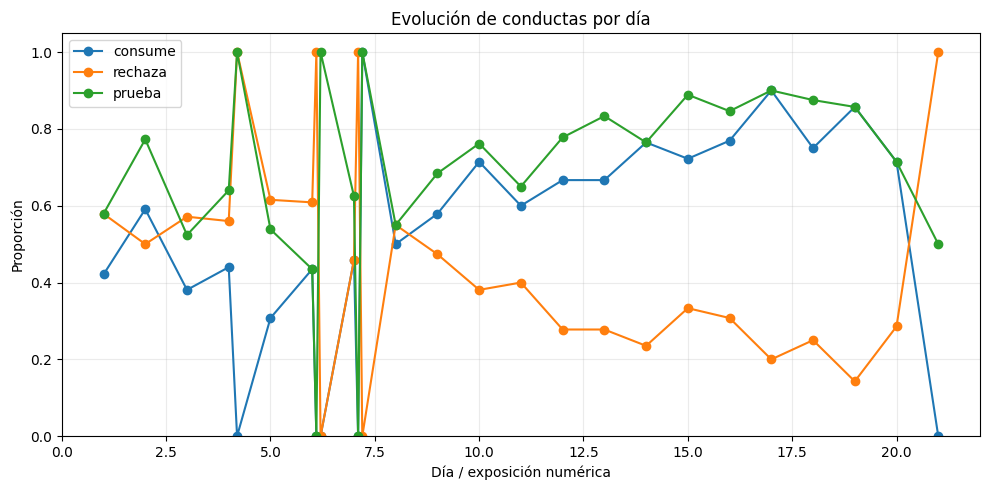

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trend_day['dia_num'], trend_day['consume_rate'], marker='o', label='consume')
ax.plot(trend_day['dia_num'], trend_day['rechaza_rate'], marker='o', label='rechaza')
ax.plot(trend_day['dia_num'], trend_day['prueba_rate'], marker='o', label='prueba')
ax.set_xlabel('Día / exposición numérica')
ax.set_ylabel('Proporción')
ax.set_ylim(0, 1.05)
ax.set_title('Evolución de conductas por día')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '01_tendencia_conductas.png', dpi=160, bbox_inches='tight')
plt.show()

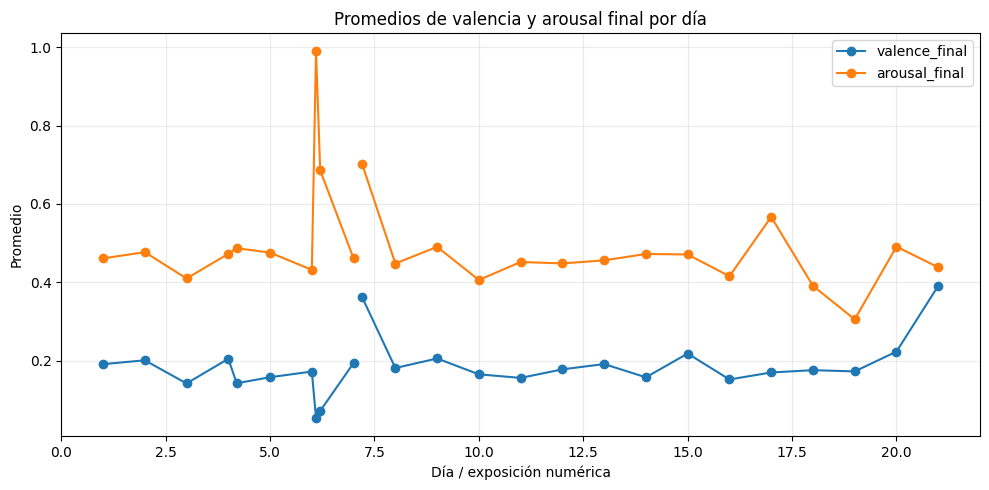

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trend_day['dia_num'], trend_day['valence_final_mean'], marker='o', label='valence_final')
ax.plot(trend_day['dia_num'], trend_day['arousal_final_mean'], marker='o', label='arousal_final')
ax.set_xlabel('Día / exposición numérica')
ax.set_ylabel('Promedio')
ax.set_title('Promedios de valencia y arousal final por día')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '01_tendencia_valence_arousal.png', dpi=160, bbox_inches='tight')
plt.show()

## 9. Espacio valencia–arousal

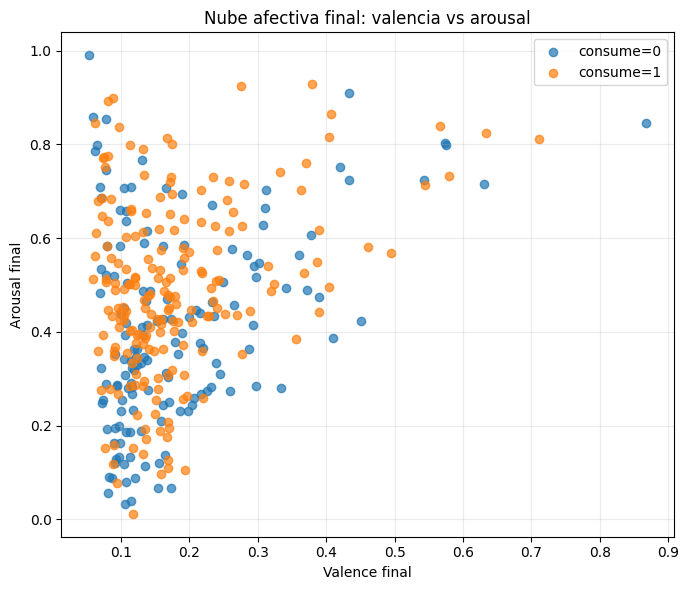

In [ ]:
plot_df = df.dropna(subset=['valence_final','arousal_final']).copy()
fig, ax = plt.subplots(figsize=(7, 6))
for label, sub in plot_df.groupby('consume'):
    ax.scatter(sub['valence_final'], sub['arousal_final'], alpha=0.7, label=f'consume={int(label)}')
ax.set_xlabel('Valence final')
ax.set_ylabel('Arousal final')
ax.set_title('Nube afectiva final: valencia vs arousal')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '01_scatter_valence_arousal.png', dpi=160, bbox_inches='tight')
plt.show()

## 10. Correlaciones exploratorias

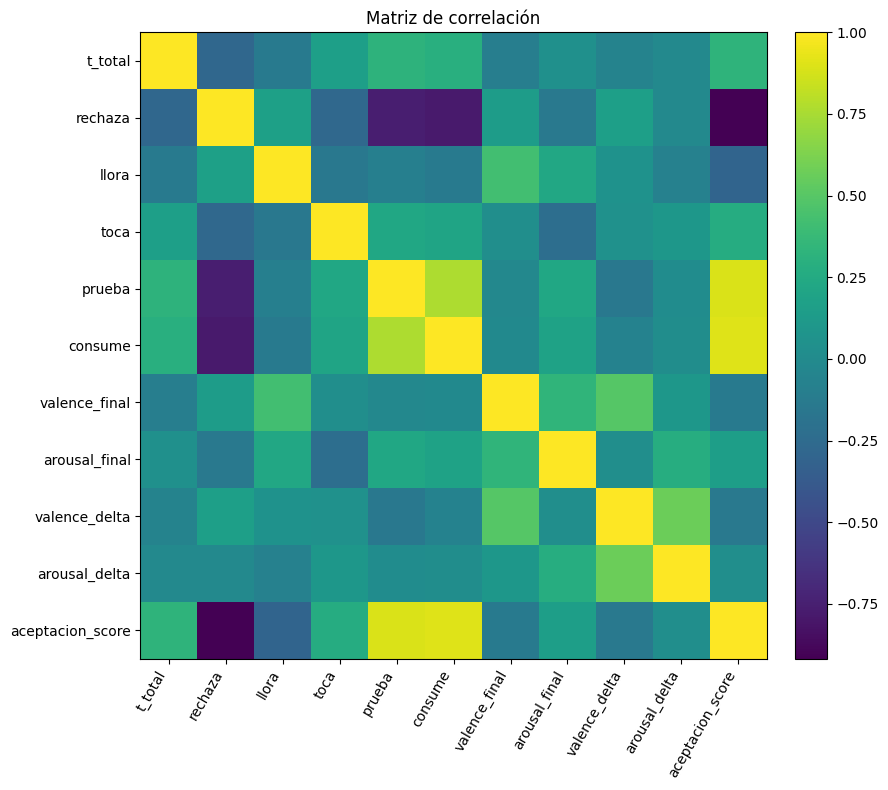

,t_total,rechaza,llora,toca,prueba,consume,valence_final,arousal_final,valence_delta,arousal_delta,aceptacion_score
t_total,1.000,-0.279,-0.128,0.168,0.324,0.290,-0.097,0.042,-0.062,-0.013,0.329
rechaza,-0.279,1.000,0.174,-0.269,-0.756,-0.777,0.139,-0.142,0.162,-0.012,-0.917
llora,-0.128,0.174,1.000,-0.149,-0.093,-0.127,0.419,0.234,0.058,-0.075,-0.302
toca,0.168,-0.269,-0.149,1.000,0.229,0.202,0.029,-0.228,0.054,0.097,0.271
prueba,0.324,-0.756,-0.093,0.229,1.000,0.764,-0.020,0.223,-0.150,0.012,0.891
consume,0.290,-0.777,-0.127,0.202,0.764,1.000,-0.011,0.189,-0.067,0.026,0.909
valence_final,-0.097,0.139,0.419,0.029,-0.020,-0.011,1.000,0.337,0.496,0.099,-0.125
arousal_final,0.042,-0.142,0.234,-0.228,0.223,0.189,0.337,1.000,0.029,0.279,0.160
valence_delta,-0.062,0.162,0.058,0.054,-0.150,-0.067,0.496,0.029,1.000,0.569,-0.144
arousal_delta,-0.013,-0.012,-0.075,0.097,0.012,0.026,0.099,0.279,0.569,1.000,0.027


In [ ]:
corr_cols = ['t_total','rechaza','llora','toca','prueba','consume','valence_final','arousal_final','valence_delta','arousal_delta','aceptacion_score']
corr = df[corr_cols].corr(numeric_only=True)
corr.round(3).to_csv(OUTPUT_DIR / '01_correlation_matrix.csv')

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=60, ha='right')
ax.set_yticklabels(corr_cols)
ax.set_title('Matriz de correlación')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '01_correlation_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

corr.round(3)

## 11. Hallazgos descriptivos preliminares

- La base contiene registros longitudinales por infante, pero no todos los infantes tienen el mismo número de observaciones.
- El etiquetado de `dia` mezcla números simples con sufijos como `E` y `P`; por eso conviene trabajar con `dia_num` y conservar `fase_dia`.
- Las variables de segunda prueba (`p2`) y algunas mediciones de valencia/arousal presentan alta ausencia por `FIT_FAILED` u otros tokens de error.
- Las tasas de `consume`, `prueba` y `rechaza` permiten construir un resumen conductual que complementa el espacio afectivo de valencia–arousal.
- El análisis por día sugiere una tendencia de mayor consumo y menor rechazo en exposiciones posteriores, aunque hay heterogeneidad clara entre infantes.

In [ ]:
# Guardamos una versión limpia para reutilizar en los siguientes notebooks.
df.to_csv(OUTPUT_DIR / 'babyface_cleaned.csv', index=False)
print(f"Archivos guardados en: {OUTPUT_DIR.resolve()}")

Archivos guardados en: /mnt/data/babyface_outputs
